## Section 1 : Data Loading 

In [274]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [275]:
df1 = pd.read_csv("dataset/olist_order_items_dataset.csv")
df2 = pd.read_csv("dataset/olist_orders_dataset.csv")
df3 = pd.read_csv("dataset/olist_products_dataset.csv")
df4 = pd.read_csv("dataset/product_category_name_translation.csv")
df5 = pd.read_csv("dataset/olist_order_reviews_dataset.csv")


## Section 2 : Delivery Analysis 

In [276]:
shipping_limit_date_col = df1["shipping_limit_date"]
order_delivered_carrier_date_col = df2["order_delivered_carrier_date"]
order_delivered_customer_date_col = df2["order_delivered_customer_date"]
order_estimated_delivery_date_col = df2["order_estimated_delivery_date"]


p1 = df3[["product_id","product_category_name"]]
p2 = df4[["product_category_name","product_category_name_english"]]

In [278]:
customers = pd.read_csv("dataset/olist_customers_dataset.csv")
orders = pd.read_csv("dataset/olist_orders_dataset.csv")
payments = pd.read_csv("dataset/olist_order_payments_dataset.csv")


### Part A : Core Delivery Analysis

In [ ]:
def separate_date_time(column):
    date_column = column.apply(lambda col_value : col_value.split(" ")[0])
    time_column = column.apply(lambda col_value : col_value.split(" ")[1])
    return date_column,time_column

In [ ]:
print("count of nan of customer delivery : " , order_delivered_customer_date_col.isna().sum())
print("coutn of nan of estimated customer delivery : " , order_estimated_delivery_date_col.isna().sum())

count of nan of customer delivery :  2965
coutn of nan of estimated customer delivery :  0


In [ ]:
customer_delivery = order_delivered_customer_date_col
estimated_delivery = order_estimated_delivery_date_col



In [ ]:
customer_delivery_nan = customer_delivery[customer_delivery.isna()]
print("count of nan values in customer delivery date : ",len(customer_delivery_nan))

count of nan values in customer delivery date :  2965


In [ ]:
customer_delivery_non_nan = customer_delivery[customer_delivery.notna()]
print("count of non-nan values in customer delivery date : ",customer_delivery_non_nan.count())

count of non-nan values in customer delivery date :  96476


In [ ]:
total_orders_placed = estimated_delivery

In [ ]:
total_number_of_orders = len(order_estimated_delivery_date_col)
delivered_orders = len(customer_delivery_non_nan)
non_delivered_orders = len(customer_delivery_nan)

print("total numbers of orders : ",total_number_of_orders)
print("total number of delivered orders : ",delivered_orders)
print("total number of non delivered orders : ",non_delivered_orders)

total numbers of orders :  99441
total number of delivered orders :  96476
total number of non delivered orders :  2965


In [ ]:
customer_delivery_non_nan_date_column = separate_date_time(customer_delivery_non_nan)[0]
print(customer_delivery_non_nan_date_column)

0        2017-10-10
1        2018-08-07
2        2018-08-17
3        2017-12-02
4        2018-02-16
            ...    
99436    2017-03-17
99437    2018-02-28
99438    2017-09-21
99439    2018-01-25
99440    2018-03-16
Name: order_delivered_customer_date, Length: 96476, dtype: object


In [ ]:
total_orders_place_date_column = separate_date_time(total_orders_placed)[0]
print(total_orders_place_date_column)

0        2017-10-18
1        2018-08-13
2        2018-09-04
3        2017-12-15
4        2018-02-26
            ...    
99436    2017-03-28
99437    2018-03-02
99438    2017-09-27
99439    2018-02-15
99440    2018-04-03
Name: order_estimated_delivery_date, Length: 99441, dtype: object


In [ ]:
# step 1 Converting to DateTime 
total_orders_place_date_column = pd.to_datetime(total_orders_place_date_column)
customer_delivery_non_nan_date_column = pd.to_datetime(customer_delivery_non_nan_date_column)
customer_delivery_nan = pd.to_datetime(customer_delivery_nan)

In [ ]:
# step 2 Converting to MONTH 
total_month = total_orders_place_date_column.dt.to_period("M").astype(str)
delivered_month = customer_delivery_non_nan_date_column.dt.to_period("M").astype(str)


In [ ]:
# step 3 COUNT per month
total_orders = total_month.value_counts().sort_index()
delivered_orders = delivered_month.value_counts().sort_index()


In [ ]:
# step 4 Create trend dataframe 
plot_df = pd.DataFrame({
    'total_orders': total_orders,
    'delivered_orders': delivered_orders
}).fillna(0).reset_index()

plot_df = plot_df.rename(columns={'index': 'month'})

In [ ]:
# step 5 convert for seaborn .. 
plot_df_melt = plot_df.melt(id_vars='month',
                            var_name='type',
                            value_name='count')

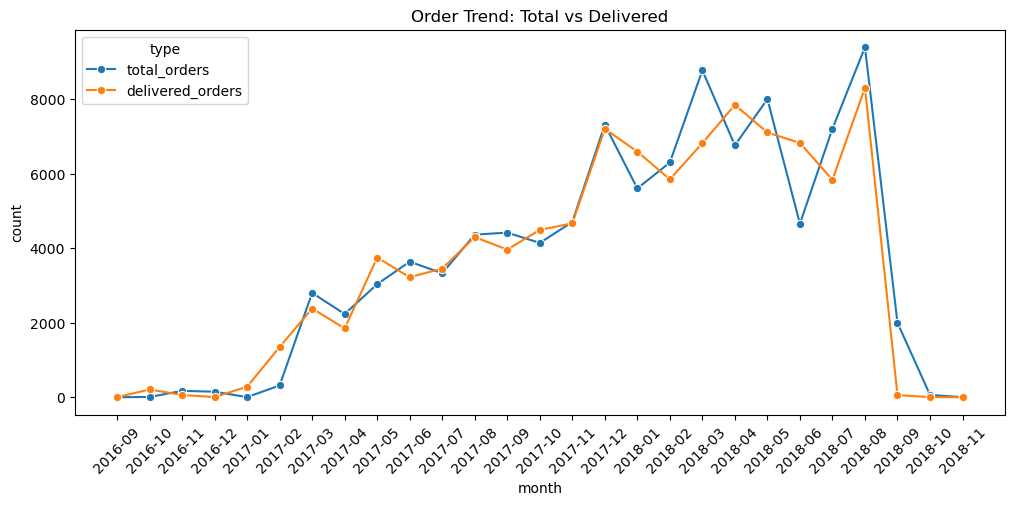

In [ ]:
# step 6 - Trend Plot (Main Graph)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=plot_df_melt,
    x='month',
    y='count',
    hue='type',
    marker='o'
)

plt.xticks(rotation=45)
plt.title("Order Trend: Total vs Delivered")
plt.show()

In [ ]:
# step 1 - get counts 
total_orders = len(total_orders_place_date_column)
delivered_orders = len(customer_delivery_non_nan_date_column)
not_delivered = len(customer_delivery_nan)

In [ ]:
# step 2 - create summary table 
summary_df = pd.DataFrame({
    'type': ['Total Orders', 'Delivered Orders', 'Not Delivered'],
    'count': [total_orders, delivered_orders, not_delivered]
})

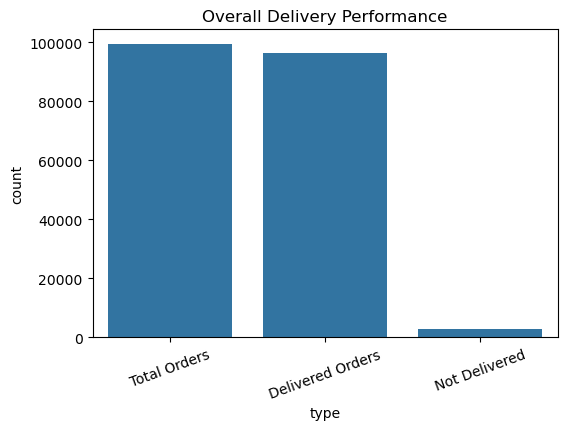

In [ ]:
# step 3 - plot bar graph 
plt.figure(figsize=(6,4))

sns.barplot(data=summary_df, x='type', y='count')

plt.title("Overall Delivery Performance")
plt.xticks(rotation=20)
plt.show()

### Part B : Delay Analysis

In [ ]:
data_delivered = pd.to_datetime(order_delivered_customer_date_col)
data_estimated = pd.to_datetime(order_estimated_delivery_date_col)

In [ ]:
actual_delivery_delay = data_delivered - data_estimated
print(actual_delivery_delay)

0        -8 days +21:25:13
1        -6 days +15:27:45
2       -18 days +18:06:29
3       -13 days +00:28:42
4       -10 days +18:17:02
               ...        
99436   -11 days +15:08:01
99437    -2 days +17:37:56
99438    -6 days +11:24:17
99439   -21 days +23:32:54
99440   -18 days +13:08:30
Length: 99441, dtype: timedelta64[ns]


In [ ]:
early_deliveries = actual_delivery_delay[actual_delivery_delay < pd.Timedelta(days=0)]
print(early_deliveries)

0        -8 days +21:25:13
1        -6 days +15:27:45
2       -18 days +18:06:29
3       -13 days +00:28:42
4       -10 days +18:17:02
               ...        
99436   -11 days +15:08:01
99437    -2 days +17:37:56
99438    -6 days +11:24:17
99439   -21 days +23:32:54
99440   -18 days +13:08:30
Length: 88649, dtype: timedelta64[ns]


In [ ]:
delay_deliveries = actual_delivery_delay[actual_delivery_delay > pd.Timedelta(days=0)]
print(delay_deliveries)

20      11 days 22:23:46
25       9 days 22:03:54
35       0 days 00:59:25
41       7 days 18:59:23
57       1 days 13:28:46
              ...       
99396    5 days 00:03:26
99397    3 days 19:59:49
99423   21 days 17:06:59
99425    2 days 00:48:31
99432    8 days 15:45:14
Length: 7827, dtype: timedelta64[ns]


In [ ]:
on_time_deliveries = actual_delivery_delay[actual_delivery_delay == pd.Timedelta(days=0)]
print(on_time_deliveries)

Series([], dtype: timedelta64[ns])


In [ ]:
summary_df = pd.DataFrame({
    "category": ["Early", "Late", "On Time"],
    "count": [
        len(early_deliveries),
        len(delay_deliveries),
        len(on_time_deliveries)
    ]
})


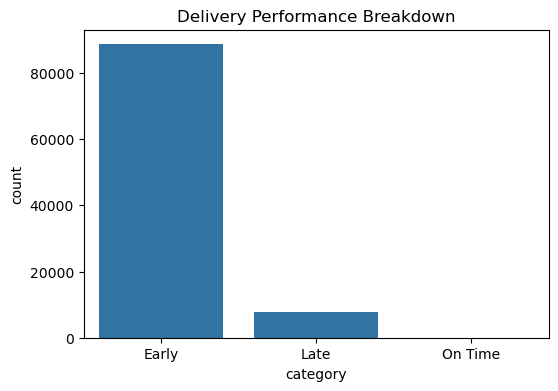

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=summary_df,
    x="category",
    y="count"
)

plt.title("Delivery Performance Breakdown")
plt.show()

### Part C : Category Wise Analysis 

In [ ]:
p1_product_category_name_null_values_sum = p1["product_category_name"].isna().sum()
p2_product_category_name_null_values_sum = p2["product_category_name"].isna().sum()

In [ ]:
null_values_of_p1_product_category_name  = p1_product_category_name_null_values_sum
print(null_values_of_p1_product_category_name)

610


In [ ]:
print(p2_product_category_name_null_values_sum)

0


In [ ]:
unmatched_total_values = len(p1[~p1["product_category_name"].isin(p2["product_category_name"])])
print(unmatched_total_values)

623


In [ ]:
# Difference values meaning , Those values which p1 product category name didn't match with p2 product cateogry name.. 
difference =  unmatched_total_values - null_values_of_p1_product_category_name
print(difference)

13


In [ ]:
product_category_df = p1.merge(p2,on="product_category_name")
print(len(product_category_df))

32328


### 📊 Data Merge Summary (Product Category Mapping)

📦 Initial Data

________________________________________________________

Total rows in p1 (products dataset): 32,951

Total rows in p2 (category translation): 71



❌ Data Loss During Merge (INNER JOIN)

_____________________________________________________________


1. Missing Category Values

product_category_name = NaN

Rows removed: 610



2. Unmatched Category Names

Categories present in p1 but NOT in p2

Rows removed: 13



✅ Final Result After Merge

32951 - 610 - 13 = 32328

Final rows after merge: 32,328

🧠 Key Insight

The reduction in rows happened because INNER JOIN keeps only rows where product_category_name exists in both datasets.

In [ ]:
product_category_df.drop("product_category_name",axis=1,inplace=True)
product_category_df.rename(columns={"product_category_name_english":"product_category_name"},inplace=True)


In [ ]:

result = product_category_df.groupby("product_category_name")
print(product_category_df)

                             product_id      product_category_name
0      1e9e8ef04dbcff4541ed26657ea517e5                  perfumery
1      3aa071139cb16b67ca9e5dea641aaa2f                        art
2      96bd76ec8810374ed1b65e291975717f             sports_leisure
3      cef67bcfe19066a932b7673e239eb23d                       baby
4      9dc1a7de274444849c219cff195d0b71                 housewares
...                                 ...                        ...
32323  a0b7d5a992ccda646f2d34e418fff5a0            furniture_decor
32324  bf4538d88321d0fd4412a93c974510e6  construction_tools_lights
32325  9a7c6041fa9592d9d9ef6cfe62a71f8c             bed_bath_table
32326  83808703fc0706a22e264b9d75f04a2e      computers_accessories
32327  106392145fca363410d287a815be6de4             bed_bath_table

[32328 rows x 2 columns]


In [ ]:
complete_df_temp = product_category_df.merge(df1,on="product_id")

In [ ]:
complete_df = complete_df_temp.merge(df2,on="order_id")

In [ ]:
print(complete_df.dtypes)
print(len(complete_df))

product_id                        object
product_category_name             object
order_id                          object
order_item_id                      int64
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
dtype: object
111023


In [ ]:
useful_data = complete_df[["product_id","product_category_name","order_delivered_customer_date","order_estimated_delivery_date"]]


In [ ]:
print(useful_data.dtypes)

product_id                       object
product_category_name            object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


In [ ]:
df = useful_data.copy()

df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])


In [ ]:
df["delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days


In [ ]:
category_summary = df.groupby("product_category_name")["delay_days"].mean().reset_index()
category_summary.columns = ["category", "avg_delay"]


In [ ]:
#  Best performing (most early deliveries)
best_10 = category_summary.sort_values("avg_delay").head(10)

#  Worst performing (least early / closest to delay)
worst_10 = category_summary.sort_values("avg_delay", ascending=False).head(10)

# Combine for better comparison
heat_data = pd.concat([best_10, worst_10])


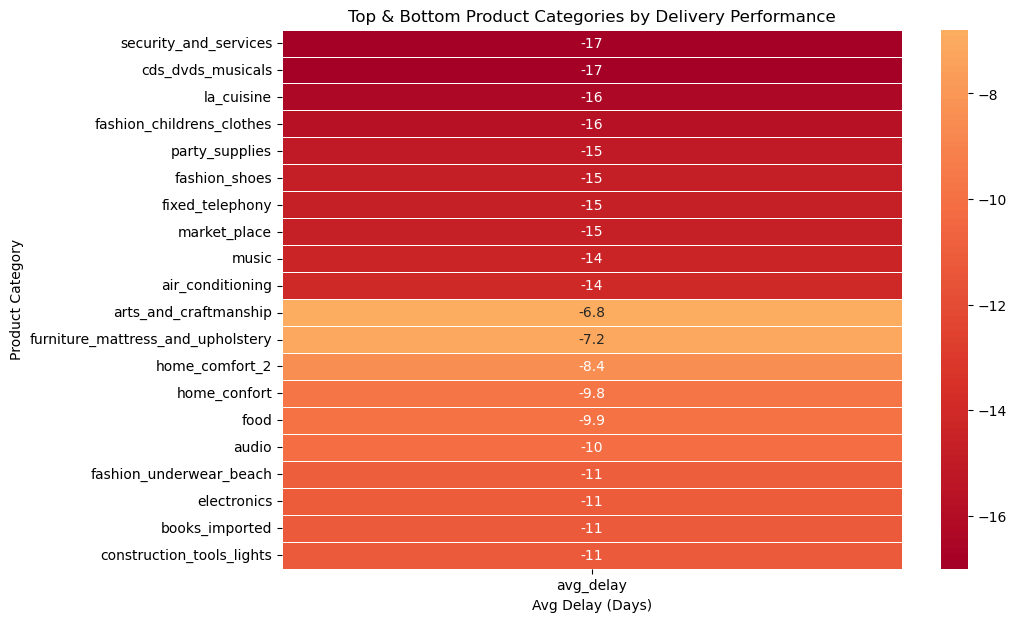

In [ ]:
# HeatMap

plt.figure(figsize=(10, 7))

heat_matrix = heat_data.set_index("category")

sns.heatmap(
    heat_matrix,
    annot=True,
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar=True
)

plt.title("Top & Bottom Product Categories by Delivery Performance")
plt.xlabel("Avg Delay (Days)")
plt.ylabel("Product Category")

plt.show()


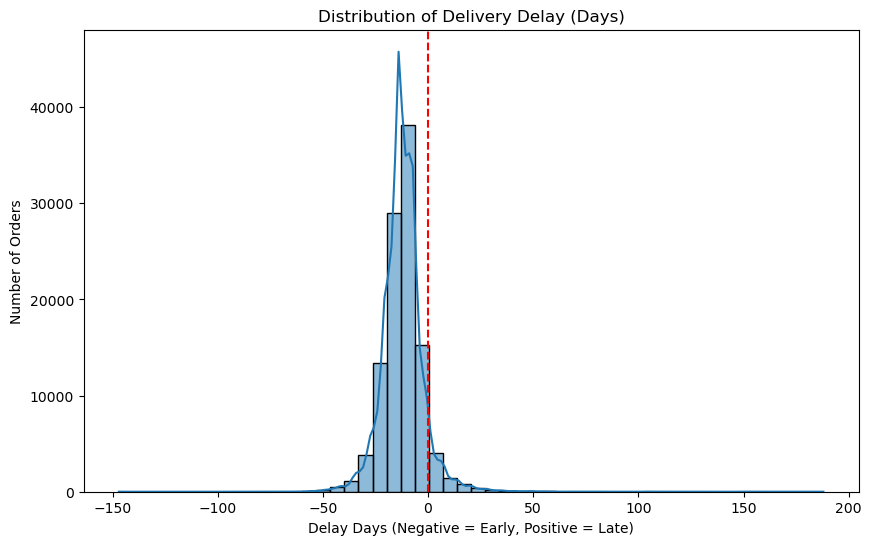

In [ ]:
# Distrbution of Delay 

plt.figure(figsize=(10, 6))

sns.histplot(df["delay_days"], bins=50, kde=True)

plt.axvline(0, color="red", linestyle="--")

plt.title("Distribution of Delivery Delay (Days)")
plt.xlabel("Delay Days (Negative = Early, Positive = Late)")
plt.ylabel("Number of Orders")

plt.show()



In [ ]:
# Business KPI 

df["delivery_type"] = df["delay_days"].apply(
    lambda x: "Early" if x < 0 else ("Late" if x > 0 else "On Time")
)

kpi = df["delivery_type"].value_counts(normalize=True) * 100

print("\n📊 DELIVERY KPI (%)")
print(kpi)




📊 DELIVERY KPI (%)
delivery_type
Early      90.131774
Late        6.439206
On Time     3.429019
Name: proportion, dtype: float64


### PART D : DELIVERY IMPACT ON CUSTOMER 

In [ ]:
first_data = df5[["order_id","review_score"]]
print(first_data.head(5))

                           order_id  review_score
0  73fc7af87114b39712e6da79b0a377eb             4
1  a548910a1c6147796b98fdf73dbeba33             5
2  f9e4b658b201a9f2ecdecbb34bed034b             5
3  658677c97b385a9be170737859d3511b             5
4  8e6bfb81e283fa7e4f11123a3fb894f1             5


In [ ]:
second_data = df2[["order_delivered_customer_date","order_estimated_delivery_date","order_id"]]
print(second_data.head(5))

  order_delivered_customer_date order_estimated_delivery_date  \
0           2017-10-10 21:25:13           2017-10-18 00:00:00   
1           2018-08-07 15:27:45           2018-08-13 00:00:00   
2           2018-08-17 18:06:29           2018-09-04 00:00:00   
3           2017-12-02 00:28:42           2017-12-15 00:00:00   
4           2018-02-16 18:17:02           2018-02-26 00:00:00   

                           order_id  
0  e481f51cbdc54678b7cc49136f2d6af7  
1  53cdb2fc8bc7dce0b6741e2150273451  
2  47770eb9100c2d0c44946d9cf07ec65d  
3  949d5b44dbf5de918fe9c16f97b45f8a  
4  ad21c59c0840e6cb83a9ceb5573f8159  


In [ ]:
df = first_data.merge(second_data,on="order_id")

In [ ]:
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])

df["delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

In [ ]:
# 1 Simple Relationship 
df[["delay_days", "review_score"]].corr()

,delay_days,review_score
delay_days,1.000000,-0.266764
review_score,-0.266764,1.000000


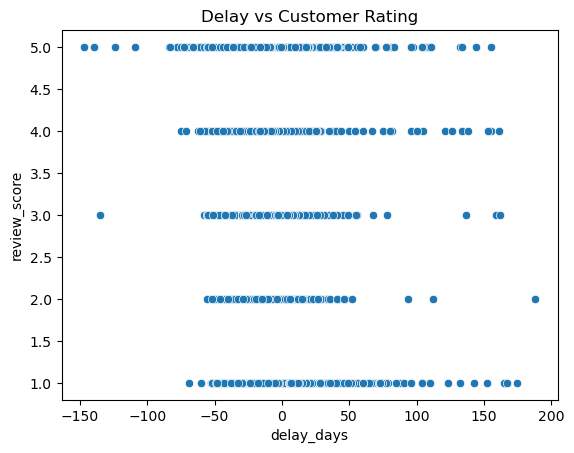

In [ ]:
# 2 Visual Relationship
sns.scatterplot(x="delay_days", y="review_score", data=df)
plt.title("Delay vs Customer Rating")
plt.show()

In [ ]:
# 3 Binning Approach (most important for business)
bins = [-100, -5, 0, 5, 10, 100]

labels = ["Very Early", "Early", "Slight Delay", "Delay", "Severe Delay"]

df["delay_group"] = pd.cut(df["delay_days"], bins=bins, labels=labels)

In [ ]:
df.groupby("delay_group")["review_score"].mean()

C:\Users\nepal\AppData\Local\Temp\ipykernel_10736\79439428.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("delay_group")["review_score"].mean()


delay_group
Very Early      4.306345
Early           4.119012
Slight Delay    2.987541
Delay           1.774665
Severe Delay    1.688312
Name: review_score, dtype: float64

C:\Users\nepal\AppData\Local\Temp\ipykernel_10736\3862685032.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("delay_group")["review_score"].mean().plot(kind="bar")


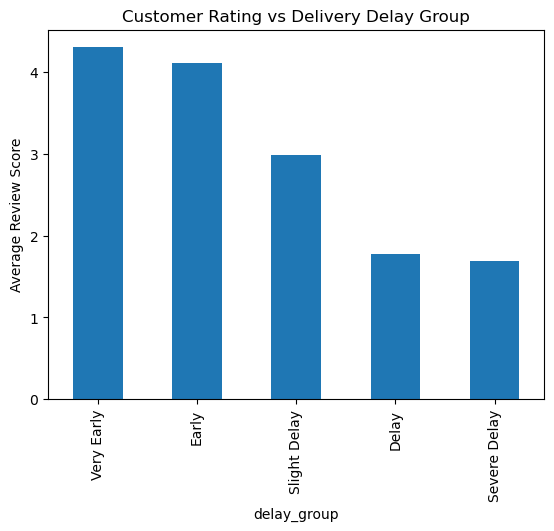

In [ ]:
# 4 VISUAL IMPACT (INSIGHT)
df.groupby("delay_group")["review_score"].mean().plot(kind="bar")
plt.title("Customer Rating vs Delivery Delay Group")
plt.ylabel("Average Review Score")
plt.show()

##  SECTION 3: CUSTOMER RFM ANALYSIS

In [279]:
# Step 1 : Merge Datasets 
df = orders.merge(customers, on="customer_id")
df = df.merge(payments, on="order_id")

In [280]:
# Step 2 : Convert datetime 
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

In [281]:
# Step 3 : Create Customer Level DAta 
rfm = df.groupby("customer_unique_id").agg(
    last_purchase=("order_purchase_timestamp", "max"),  # 👈 THIS LINE CREATES last_purchase
    frequency=("order_id", "count"),
    monetary=("payment_value", "sum")
).reset_index()

In [ ]:
# Step 4 : Convert last purchase to datetime 
rfm["last_purchase"] = pd.to_datetime(rfm["last_purchase"])

In [283]:
# Step 5 : Calculate Recency 
today = df["order_purchase_timestamp"].max()

rfm["recency"] = (today - rfm["last_purchase"]).dt.days

In [284]:
# Step 6 : Create RFM Scores 

# Recency (lower is better → reverse labels)
rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1])

# Frequency (use rank to avoid error)
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

# Monetary
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5])

In [285]:
# Step 7 : Combine RFM score 
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)
)

In [ ]:
# STEP 8 : Simple Segmentation 


# Convert scores to int
rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

# Segmentation
def segment(row):

    # Champions (best customers)
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champion"

    # Loyal Customers (frequent + decent spending, recent enough)
    elif row["F_score"] >= 4 and row["M_score"] >= 3:
        return "Loyal"

    # Potential / New Customers (recent but not strong yet)
    elif row["R_score"] >= 4:
        return "Potential"

    # Others (inactive or low value)
    else:
        return "Others"

rfm["segment"] = rfm.apply(segment, axis=1) # “axis=1 means apply function to each row, and the returned values become a new column.”

In [287]:
# Step 9 : Adding time (for over time analysis)
df["year"] = df["order_purchase_timestamp"].dt.year

In [288]:
# Step 10 : Merge Segment back 
df = df.merge(rfm[["customer_unique_id", "segment"]], on="customer_unique_id")

In [289]:
# Step 11 : Revenu by segment over time 
segment_year = df.groupby(["year", "segment"])["payment_value"].sum().reset_index()

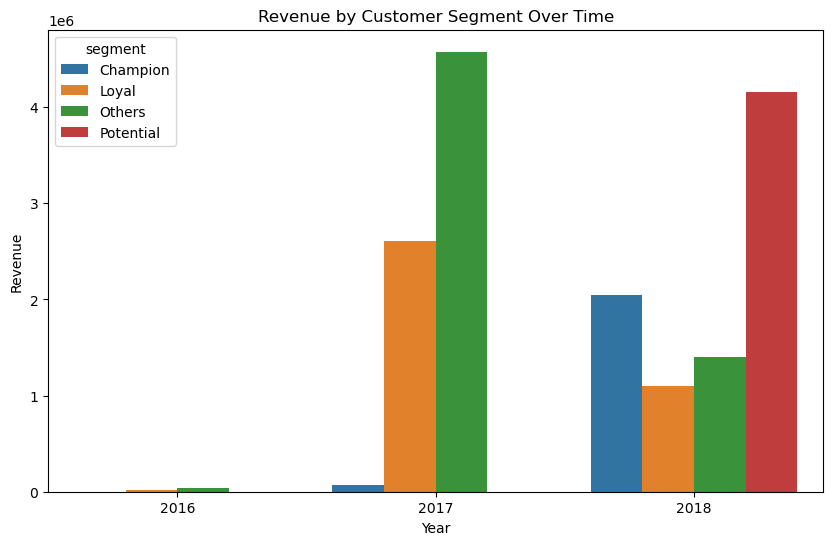

In [290]:
# Step 12 : Bar Graph 
plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_year,
    x="year",
    y="payment_value",
    hue="segment"
)

plt.title("Revenue by Customer Segment Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.show()

## SECTION 4 : CUSTOMER COUNT BY SEGMENT OVER TIME 

In [291]:
count_segment = df.groupby(["year", "segment"])["customer_unique_id"].nunique().reset_index()

In [292]:
count_segment = count_segment.rename(columns={
    "customer_unique_id": "customer_count"
})

<Axes: xlabel='year', ylabel='customer_count'>

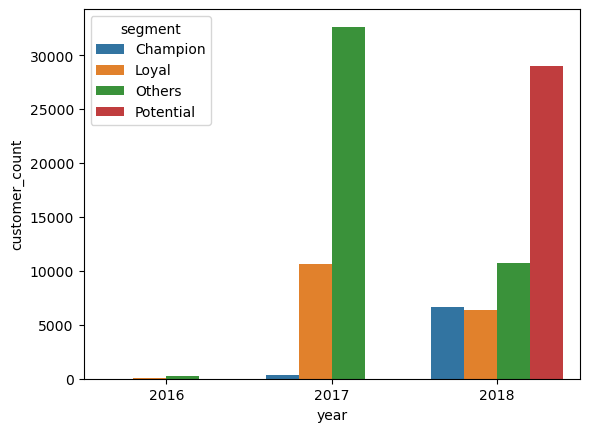

In [293]:
sns.barplot(
    data=count_segment,
    x="year",
    y="customer_count",
    hue="segment"
)